<a href="https://colab.research.google.com/github/jananibabu17112004-ctrl/variant-pathogenicity-streamlit17/blob/main/Hybridmodelfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ClinVar compressed file
!wget -c https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz

# hg38 reference genome
!wget -c https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz

# package for reading fasta efficiently
!pip -q install pyfaidx

--2026-03-22 16:28:21--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 435424032 (415M) [application/x-gzip]
Saving to: ‘variant_summary.txt.gz’

variant_summary.txt 100%[===================>] 415.25M  17.6MB/s    in 26s     

2026-03-22 16:28:48 (16.1 MB/s) - ‘variant_summary.txt.gz’ saved [435424032/435424032]

--2026-03-22 16:28:48--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983659424 (938M) [application/x-gzip]
Saving to: ‘hg38.fa.gz’

hg38.f

In [ ]:
import pandas as pd

usecols = [
    "Assembly",
    "Type",
    "ClinicalSignificance",
    "Chromosome",
    "Start",
    "ReferenceAllele",
    "AlternateAllele"
]

clinvar = pd.read_csv(
    "variant_summary.txt.gz",
    sep="\t",
    compression="gzip",
    usecols=usecols,
    low_memory=False
)

print("Loaded ClinVar shape:", clinvar.shape)
clinvar.head()

Loaded ClinVar shape: (8907105, 7)


,Type,ClinicalSignificance,Assembly,Chromosome,Start,ReferenceAllele,AlternateAllele
0,Indel,Pathogenic/Likely pathogenic,GRCh37,7,4820844,na,na
1,Indel,Pathogenic/Likely pathogenic,GRCh38,7,4781213,na,na
2,Deletion,Pathogenic,GRCh37,7,4827361,na,na
3,Deletion,Pathogenic,GRCh38,7,4787730,na,na
4,single nucleotide variant,Uncertain significance,GRCh37,15,85342440,na,na


In [ ]:
clinvar = clinvar[
    (clinvar["Assembly"] == "GRCh38") &
    (clinvar["Type"] == "single nucleotide variant") &
    (clinvar["ClinicalSignificance"].isin(["Pathogenic", "Benign"]))
].copy()

clinvar["label"] = clinvar["ClinicalSignificance"].map({
    "Benign": 0,
    "Pathogenic": 1
})

clinvar = clinvar[
    ["Chromosome", "Start", "ReferenceAllele", "AlternateAllele", "label"]
].dropna()

print("Filtered ClinVar shape:", clinvar.shape)
print(clinvar["label"].value_counts())
clinvar.head()

Filtered ClinVar shape: (266416, 5)
label
0    181059
1     85357
Name: count, dtype: int64


,Chromosome,Start,ReferenceAllele,AlternateAllele,label
7,11,126275389,na,na,1
23,6,26093008,na,na,0
31,6,26093215,na,na,1
35,2,19989284,na,na,1
37,2,19945787,na,na,1


In [ ]:
n_per_class = 5000   # start small and safe

benign = clinvar[clinvar["label"] == 0].sample(
    n=min(n_per_class, (clinvar["label"] == 0).sum()),
    random_state=42
)

pathogenic = clinvar[clinvar["label"] == 1].sample(
    n=min(n_per_class, (clinvar["label"] == 1).sum()),
    random_state=42
)

clinvar_small = pd.concat([benign, pathogenic], axis=0)
clinvar_small = clinvar_small.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced subset shape:", clinvar_small.shape)
print(clinvar_small["label"].value_counts())
clinvar_small.head()

Balanced subset shape: (10000, 5)
label
1    5000
0    5000
Name: count, dtype: int64


,Chromosome,Start,ReferenceAllele,AlternateAllele,label
0,2,39056704,na,na,1
1,20,40688623,na,na,0
2,X,153862916,na,na,0
3,7,4783555,na,na,0
4,17,1679225,na,na,0


In [ ]:
del clinvar

In [ ]:
!gunzip -f hg38.fa.gz

In [ ]:
from pyfaidx import Fasta

genome = Fasta("hg38.fa")
print("hg38 loaded successfully")

hg38 loaded successfully


In [ ]:
def get_sequence(chrom, pos, window=50):
    try:
        seq = genome[chrom][pos - window - 1 : pos + window].seq.upper()
        return seq if len(seq) == 101 else None
    except:
        return None

clinvar_small["chrom"] = "chr" + clinvar_small["Chromosome"].astype(str)
clinvar_small["pos"] = clinvar_small["Start"].astype(int)

seqs = []
for chrom, pos in zip(clinvar_small["chrom"], clinvar_small["pos"]):
    seqs.append(get_sequence(chrom, pos, window=50))

clinvar_small["seq_101"] = seqs
clinvar_small = clinvar_small.dropna(subset=["seq_101"]).reset_index(drop=True)

print("After sequence extraction:", clinvar_small.shape)
clinvar_small.head()

After sequence extraction: (9975, 8)


,Chromosome,Start,ReferenceAllele,AlternateAllele,label,chrom,pos,seq_101
0,2,39056704,na,na,1,chr2,39056704,GTCATAAAAAGAAACTTAAGAAAAAAATAGAAAAGCTCAGTTTCCT...
1,20,40688623,na,na,0,chr20,40688623,TGGTAGTTGCTCGCCATCCAGTACAGATCCTCGAGGTGTGTCTTCT...
2,X,153862916,na,na,0,chrX,153862916,TGCTGCCAAAGGCCTTCTCCTCGTTGTCACTGCAGAGGCACAGGGC...
3,7,4783555,na,na,0,chr7,4783555,CAGGTCCTTCCCTGAGGGCCCATGGTGGGTTGGGAGTGTGGGGGGC...
4,17,1679225,na,na,0,chr17,1679225,ATTTGGTGGCTTTGAAGGAGCGGAACAAATACCTGAGGTGGGAACA...


In [ ]:
clinvar_small.to_csv("clinvar_seq_10k.csv", index=False)
print("Saved as clinvar_seq_10k.csv")

Saved as clinvar_seq_10k.csv


In [ ]:
def gc_content(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

def is_transition(ref, alt):
    transitions = {("A","G"), ("G","A"), ("C","T"), ("T","C")}
    return 1 if (ref, alt) in transitions else 0

clinvar_small["gc_content"] = clinvar_small["seq_101"].apply(gc_content)
clinvar_small["is_transition"] = clinvar_small.apply(
    lambda x: is_transition(str(x["ReferenceAllele"]), str(x["AlternateAllele"])),
    axis=1
)

clinvar_small["ref_A"] = (clinvar_small["ReferenceAllele"] == "A").astype(int)
clinvar_small["ref_C"] = (clinvar_small["ReferenceAllele"] == "C").astype(int)
clinvar_small["ref_G"] = (clinvar_small["ReferenceAllele"] == "G").astype(int)
clinvar_small["ref_T"] = (clinvar_small["ReferenceAllele"] == "T").astype(int)

clinvar_small["alt_A"] = (clinvar_small["AlternateAllele"] == "A").astype(int)
clinvar_small["alt_C"] = (clinvar_small["AlternateAllele"] == "C").astype(int)
clinvar_small["alt_G"] = (clinvar_small["AlternateAllele"] == "G").astype(int)
clinvar_small["alt_T"] = (clinvar_small["AlternateAllele"] == "T").astype(int)

clinvar_small.to_csv("clinvar_seq_features_10k.csv", index=False)
print("Saved as clinvar_seq_features_10k.csv")
print(clinvar_small.shape)

Saved as clinvar_seq_features_10k.csv
(9975, 18)


In [ ]:
# Core files only: safe starter set for Colab

!wget -c https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz
!wget -c https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/latest/hg38.fa.gz
!wget -c https://hgdownload.soe.ucsc.edu/goldenPath/hg38/phyloP100way/hg38.phyloP100way.bw
!wget -c https://hgdownload.soe.ucsc.edu/goldenPath/hg38/phastCons100way/hg38.phastCons100way.bw
!wget -c https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/genes/ncbiRefSeq.gtf.gz

--2026-03-22 16:40:58--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2026-03-22 16:41:00--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/latest/hg38.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1012013082 (965M) [application/x-gzip]
Saving to: ‘hg38.fa.gz’

hg38.fa.gz          100%[===================>] 965.13M  12.9MB/s    in 71s     

2026-03-22 16:42:12 (13.5 MB/s) - ‘hg38.fa.gz’ saved [1012013082/1012013082]

--2

In [ ]:
!pip -q install pyfaidx pyBigWig

In [ ]:
import pandas as pd
import numpy as np
from pyfaidx import Fasta
import pyBigWig


In [ ]:
usecols = [
    "Assembly",
    "Type",
    "ClinicalSignificance",
    "Chromosome",
    "Start",
    "ReferenceAllele",
    "AlternateAllele"
]

clinvar = pd.read_csv(
    "variant_summary.txt.gz",
    sep="\t",
    compression="gzip",
    usecols=usecols,
    low_memory=False
)

print("Raw ClinVar shape:", clinvar.shape)
clinvar.head()

Raw ClinVar shape: (8907105, 7)


,Type,ClinicalSignificance,Assembly,Chromosome,Start,ReferenceAllele,AlternateAllele
0,Indel,Pathogenic/Likely pathogenic,GRCh37,7,4820844,na,na
1,Indel,Pathogenic/Likely pathogenic,GRCh38,7,4781213,na,na
2,Deletion,Pathogenic,GRCh37,7,4827361,na,na
3,Deletion,Pathogenic,GRCh38,7,4787730,na,na
4,single nucleotide variant,Uncertain significance,GRCh37,15,85342440,na,na


In [ ]:
clinvar = clinvar[
    (clinvar["Assembly"] == "GRCh38") &
    (clinvar["Type"] == "single nucleotide variant") &
    (clinvar["ClinicalSignificance"].isin(["Pathogenic", "Benign"]))
].copy()

clinvar["label"] = clinvar["ClinicalSignificance"].map({
    "Benign": 0,
    "Pathogenic": 1
})

clinvar = clinvar[
    ["Chromosome", "Start", "ReferenceAllele", "AlternateAllele", "label"]
].dropna()

print("Filtered ClinVar shape:", clinvar.shape)
print(clinvar["label"].value_counts())
clinvar.head()

Filtered ClinVar shape: (266416, 5)
label
0    181059
1     85357
Name: count, dtype: int64


,Chromosome,Start,ReferenceAllele,AlternateAllele,label
7,11,126275389,na,na,1
23,6,26093008,na,na,0
31,6,26093215,na,na,1
35,2,19989284,na,na,1
37,2,19945787,na,na,1


In [ ]:
n_per_class = 5000   # keep this small first for 12 GB RAM

benign = clinvar[clinvar["label"] == 0].sample(
    n=min(n_per_class, (clinvar["label"] == 0).sum()),
    random_state=42
)

pathogenic = clinvar[clinvar["label"] == 1].sample(
    n=min(n_per_class, (clinvar["label"] == 1).sum()),
    random_state=42
)

clinvar_small = pd.concat([benign, pathogenic], axis=0)
clinvar_small = clinvar_small.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced subset shape:", clinvar_small.shape)
print(clinvar_small["label"].value_counts())

Balanced subset shape: (10000, 5)
label
1    5000
0    5000
Name: count, dtype: int64


In [ ]:
del clinvar

In [ ]:
!gunzip -f hg38.fa.gz

In [ ]:
genome = Fasta("hg38.fa")
print("hg38 loaded")

hg38 loaded


In [ ]:
phyloP_bw = pyBigWig.open("hg38.phyloP100way.bw")
phastCons_bw = pyBigWig.open("hg38.phastCons100way.bw")

print("phyloP and phastCons loaded")

phyloP and phastCons loaded


In [ ]:
def get_sequence(chrom, pos, window=50):
    try:
        seq = genome[chrom][pos - window - 1 : pos + window].seq.upper()
        return seq if len(seq) == 101 else None
    except:
        return None

clinvar_small["chrom"] = "chr" + clinvar_small["Chromosome"].astype(str)
clinvar_small["pos"] = clinvar_small["Start"].astype(int)

clinvar_small["seq_101"] = [
    get_sequence(chrom, pos, window=50)
    for chrom, pos in zip(clinvar_small["chrom"], clinvar_small["pos"])
]

clinvar_small = clinvar_small.dropna(subset=["seq_101"]).reset_index(drop=True)
print("After sequence extraction:", clinvar_small.shape)

After sequence extraction: (9975, 8)


In [ ]:
def get_bw_value(bw, chrom, pos):
    try:
        val = bw.values(chrom, pos - 1, pos)[0]
        if val is None or np.isnan(val):
            return 0.0
        return float(val)
    except:
        return 0.0

clinvar_small["phyloP"] = [
    get_bw_value(phyloP_bw, chrom, pos)
    for chrom, pos in zip(clinvar_small["chrom"], clinvar_small["pos"])
]

clinvar_small["phastCons"] = [
    get_bw_value(phastCons_bw, chrom, pos)
    for chrom, pos in zip(clinvar_small["chrom"], clinvar_small["pos"])
]

clinvar_small[["chrom", "pos", "phyloP", "phastCons"]].head()

,chrom,pos,phyloP,phastCons
0,chr2,39056704,7.908,1.000
1,chr20,40688623,-0.911,0.006
2,chrX,153862916,0.906,0.001
3,chr7,4783555,-1.867,0.000
4,chr17,1679225,-0.224,0.000


In [ ]:
def gc_content(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

def is_transition(ref, alt):
    transitions = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
    return 1 if (ref, alt) in transitions else 0

clinvar_small["gc_content"] = clinvar_small["seq_101"].apply(gc_content)
clinvar_small["is_transition"] = clinvar_small.apply(
    lambda x: is_transition(str(x["ReferenceAllele"]), str(x["AlternateAllele"])),
    axis=1
)

for base in ["A", "C", "G", "T"]:
    clinvar_small[f"ref_{base}"] = (clinvar_small["ReferenceAllele"] == base).astype(int)
    clinvar_small[f"alt_{base}"] = (clinvar_small["AlternateAllele"] == base).astype(int)

clinvar_small.head()

,Chromosome,Start,ReferenceAllele,AlternateAllele,label,chrom,pos,seq_101,phyloP,phastCons,gc_content,is_transition,ref_A,alt_A,ref_C,alt_C,ref_G,alt_G,ref_T,alt_T
0,2,39056704,na,na,1,chr2,39056704,GTCATAAAAAGAAACTTAAGAAAAAAATAGAAAAGCTCAGTTTCCT...,7.908,1.000,0.306931,0,0,0,0,0,0,0,0,0
1,20,40688623,na,na,0,chr20,40688623,TGGTAGTTGCTCGCCATCCAGTACAGATCCTCGAGGTGTGTCTTCT...,-0.911,0.006,0.603960,0,0,0,0,0,0,0,0,0
2,X,153862916,na,na,0,chrX,153862916,TGCTGCCAAAGGCCTTCTCCTCGTTGTCACTGCAGAGGCACAGGGC...,0.906,0.001,0.663366,0,0,0,0,0,0,0,0,0
3,7,4783555,na,na,0,chr7,4783555,CAGGTCCTTCCCTGAGGGCCCATGGTGGGTTGGGAGTGTGGGGGGC...,-1.867,0.000,0.663366,0,0,0,0,0,0,0,0,0
4,17,1679225,na,na,0,chr17,1679225,ATTTGGTGGCTTTGAAGGAGCGGAACAAATACCTGAGGTGGGAACA...,-0.224,0.000,0.504950,0,0,0,0,0,0,0,0,0


In [ ]:
clinvar_small.to_csv("clinvar_hybrid_ready_10k.csv", index=False)
print("Saved: clinvar_hybrid_ready_10k.csv")
print(clinvar_small.shape)

Saved: clinvar_hybrid_ready_10k.csv
(9975, 20)


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
df = pd.read_csv("clinvar_hybrid_ready_10k.csv")
print(df.shape)
df.head()

(9975, 20)


,Chromosome,Start,ReferenceAllele,AlternateAllele,label,chrom,pos,seq_101,phyloP,phastCons,gc_content,is_transition,ref_A,alt_A,ref_C,alt_C,ref_G,alt_G,ref_T,alt_T
0,2,39056704,na,na,1,chr2,39056704,GTCATAAAAAGAAACTTAAGAAAAAAATAGAAAAGCTCAGTTTCCT...,7.908,1.000,0.306931,0,0,0,0,0,0,0,0,0
1,20,40688623,na,na,0,chr20,40688623,TGGTAGTTGCTCGCCATCCAGTACAGATCCTCGAGGTGTGTCTTCT...,-0.911,0.006,0.603960,0,0,0,0,0,0,0,0,0
2,X,153862916,na,na,0,chrX,153862916,TGCTGCCAAAGGCCTTCTCCTCGTTGTCACTGCAGAGGCACAGGGC...,0.906,0.001,0.663366,0,0,0,0,0,0,0,0,0
3,7,4783555,na,na,0,chr7,4783555,CAGGTCCTTCCCTGAGGGCCCATGGTGGGTTGGGAGTGTGGGGGGC...,-1.867,0.000,0.663366,0,0,0,0,0,0,0,0,0
4,17,1679225,na,na,0,chr17,1679225,ATTTGGTGGCTTTGAAGGAGCGGAACAAATACCTGAGGTGGGAACA...,-0.224,0.000,0.504950,0,0,0,0,0,0,0,0,0


In [ ]:
feature_cols = [
    "phyloP", "phastCons", "gc_content", "is_transition",
    "ref_A", "ref_C", "ref_G", "ref_T",
    "alt_A", "alt_C", "alt_G", "alt_T"
]

required_cols = ["seq_101", "label"] + feature_cols
df = df[required_cols].dropna().copy()

print(df.shape)
print(df["label"].value_counts())

(9975, 14)
label
1    4999
0    4976
Name: count, dtype: int64


In [ ]:
base_to_idx = {"A": 0, "C": 1, "G": 2, "T": 3}

def one_hot_encode_dna(seq):
    arr = np.zeros((len(seq), 4), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in base_to_idx:
            arr[i, base_to_idx[base]] = 1.0
    return arr

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (6982, 14)
Val: (1496, 14)
Test: (1497, 14)


In [ ]:
scaler = StandardScaler()

train_df.loc[:, feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df.loc[:, feature_cols] = scaler.transform(val_df[feature_cols])
test_df.loc[:, feature_cols] = scaler.transform(test_df[feature_cols])

In [ ]:
class VariantDataset(Dataset):
    def __init__(self, dataframe, feature_cols):
        self.df = dataframe.reset_index(drop=True)
        self.feature_cols = feature_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        seq = one_hot_encode_dna(row["seq_101"])   # (101, 4)
        features = row[self.feature_cols].values.astype(np.float32)
        label = np.float32(row["label"])

        return {
            "seq": torch.tensor(seq, dtype=torch.float32),
            "features": torch.tensor(features, dtype=torch.float32),
            "label": torch.tensor(label, dtype=torch.float32)
        }

train_dataset = VariantDataset(train_df, feature_cols)
val_dataset = VariantDataset(val_df, feature_cols)
test_dataset = VariantDataset(test_df, feature_cols)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
class AttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.Tanh(),
            nn.Linear(input_dim // 2, 1)
        )

    def forward(self, x):
        # x: (B, L, D)
        scores = self.attn(x)                  # (B, L, 1)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(weights * x, dim=1) # (B, D)
        return pooled

In [ ]:
class HybridModel(nn.Module):
    def __init__(
        self,
        seq_input_dim=4,
        lstm_hidden_dim=64,
        transformer_dim=64,
        num_heads=4,
        num_transformer_layers=2,
        mlp_input_dim=12,
        mlp_hidden_dim=32,
        fusion_dim=128,
        dropout=0.3
    ):
        super().__init__()

        # Shared projection for sequence
        self.seq_projection = nn.Linear(seq_input_dim, transformer_dim)

        # BiLSTM branch
        self.bilstm = nn.LSTM(
            input_size=transformer_dim,
            hidden_size=lstm_hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.lstm_pool = AttentionPooling(lstm_hidden_dim * 2)

        # Transformer branch
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=num_heads,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )
        self.transformer_pool = AttentionPooling(transformer_dim)

        # MLP branch
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            nn.Linear(64, mlp_hidden_dim),
            nn.ReLU()
        )

        # Fusion head
        fusion_input_dim = (lstm_hidden_dim * 2) + transformer_dim + mlp_hidden_dim

        self.classifier = nn.Sequential(
            nn.Linear(fusion_input_dim, fusion_dim),
            nn.ReLU(),
            nn.BatchNorm1d(fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, seq, features):
        # seq: (B, 101, 4)
        x = self.seq_projection(seq)  # (B, 101, transformer_dim)

        # BiLSTM branch
        lstm_out, _ = self.bilstm(x)
        lstm_feat = self.lstm_pool(lstm_out)

        # Transformer branch
        trans_out = self.transformer(x)
        trans_feat = self.transformer_pool(trans_out)

        # MLP branch
        mlp_feat = self.mlp(features)

        # Fusion
        combined = torch.cat([lstm_feat, trans_feat, mlp_feat], dim=1)
        logits = self.classifier(combined).squeeze(1)

        return logits

In [ ]:
class AttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.Tanh(),
            nn.Linear(input_dim // 2, 1)
        )

    def forward(self, x):
        scores = self.attn(x)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(weights * x, dim=1)
        return pooled


class HybridModel(nn.Module):
    def __init__(
        self,
        seq_input_dim=4,
        lstm_hidden_dim=64,
        transformer_dim=64,
        num_heads=4,
        num_transformer_layers=2,
        mlp_input_dim=12,
        mlp_hidden_dim=32,
        fusion_dim=128,
        dropout=0.3
    ):
        super().__init__()

        self.seq_projection = nn.Linear(seq_input_dim, transformer_dim)

        self.bilstm = nn.LSTM(
            input_size=transformer_dim,
            hidden_size=lstm_hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.lstm_pool = AttentionPooling(lstm_hidden_dim * 2)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=num_heads,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )
        self.transformer_pool = AttentionPooling(transformer_dim)

        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            nn.Linear(64, mlp_hidden_dim),
            nn.ReLU()
        )

        fusion_input_dim = (lstm_hidden_dim * 2) + transformer_dim + mlp_hidden_dim

        self.classifier = nn.Sequential(
            nn.Linear(fusion_input_dim, fusion_dim),
            nn.ReLU(),
            nn.BatchNorm1d(fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, seq, features):
        x = self.seq_projection(seq)

        lstm_out, _ = self.bilstm(x)
        lstm_feat = self.lstm_pool(lstm_out)

        trans_out = self.transformer(x)
        trans_feat = self.transformer_pool(trans_out)

        mlp_feat = self.mlp(features)

        combined = torch.cat([lstm_feat, trans_feat, mlp_feat], dim=1)
        logits = self.classifier(combined).squeeze(1)

        return logits

In [ ]:
model = HybridModel(
    seq_input_dim=4,
    lstm_hidden_dim=64,
    transformer_dim=64,
    num_heads=4,
    num_transformer_layers=2,
    mlp_input_dim=len(feature_cols),
    mlp_hidden_dim=32,
    fusion_dim=128,
    dropout=0.3
).to(device)

print(model)

HybridModel(
  (seq_projection): Linear(in_features=4, out_features=64, bias=True)
  (bilstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (lstm_pool): AttentionPooling(
    (attn): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (d

In [ ]:
# class imbalance handling
class_counts = train_df["label"].value_counts().sort_index()
num_neg = class_counts.get(0, 1)
num_pos = class_counts.get(1, 1)
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.5
)

print("pos_weight:", pos_weight.item())

pos_weight: 0.9954272508621216


In [ ]:
def evaluate_model(model, loader, threshold=0.5):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            seq = batch["seq"].to(device)
            features = batch["features"].to(device)
            labels = batch["label"].to(device)

            logits = model(seq, features)
            probs = torch.sigmoid(logits)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    preds = (all_probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(all_labels, all_probs),
        "pr_auc": average_precision_score(all_labels, all_probs),
        "mcc": matthews_corrcoef(all_labels, preds)
    }

    return metrics, all_labels, all_probs

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15):
    best_val_f1 = 0.0
    best_model_path = "best_hybrid_model.pth"

    train_losses = []
    val_f1s = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            seq = batch["seq"].to(device)
            features = batch["features"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()

            logits = model(seq, features)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        val_metrics, _, _ = evaluate_model(model, val_loader, threshold=0.5)
        val_f1 = val_metrics["f1"]
        val_f1s.append(val_f1)

        scheduler.step(val_f1)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"Val Precision: {val_metrics['precision']:.4f}")
        print(f"Val Recall: {val_metrics['recall']:.4f}")
        print(f"Val F1: {val_metrics['f1']:.4f}")
        print(f"Val ROC-AUC: {val_metrics['roc_auc']:.4f}")
        print(f"Val PR-AUC: {val_metrics['pr_auc']:.4f}")
        print(f"Val MCC: {val_metrics['mcc']:.4f}")
        print("-" * 50)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)

    print("Best Val F1:", best_val_f1)
    return train_losses, val_f1s

In [ ]:
train_losses, val_f1s = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=15
)

Epoch [1/15]
Train Loss: 0.4311
Val Accuracy: 0.8342
Val Precision: 0.8210
Val Recall: 0.8560
Val F1: 0.8381
Val ROC-AUC: 0.9067
Val PR-AUC: 0.8956
Val MCC: 0.6690
--------------------------------------------------
Epoch [2/15]
Train Loss: 0.3913
Val Accuracy: 0.8402
Val Precision: 0.8230
Val Recall: 0.8680
Val F1: 0.8449
Val ROC-AUC: 0.9091
Val PR-AUC: 0.8998
Val MCC: 0.6815
--------------------------------------------------
Epoch [3/15]
Train Loss: 0.3958
Val Accuracy: 0.8416
Val Precision: 0.8558
Val Recall: 0.8227
Val F1: 0.8389
Val ROC-AUC: 0.9092
Val PR-AUC: 0.8994
Val MCC: 0.6837
--------------------------------------------------
Epoch [4/15]
Train Loss: 0.3924
Val Accuracy: 0.8429
Val Precision: 0.8562
Val Recall: 0.8253
Val F1: 0.8405
Val ROC-AUC: 0.9065
Val PR-AUC: 0.8976
Val MCC: 0.6863
--------------------------------------------------
Epoch [5/15]
Train Loss: 0.3925
Val Accuracy: 0.8396
Val Precision: 0.8320
Val Recall: 0.8520
Val F1: 0.8419
Val ROC-AUC: 0.9075
Val PR-AUC:

In [ ]:
test_metrics, y_true, y_probs = evaluate_model(model, test_loader, threshold=0.5)

print("Test Metrics")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Test Metrics
accuracy: 0.8584
precision: 0.8558
recall: 0.8627
f1: 0.8592
roc_auc: 0.9321
pr_auc: 0.9316
mcc: 0.7168


In [ ]:
y_pred = (y_probs >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[638 109]
 [103 647]]


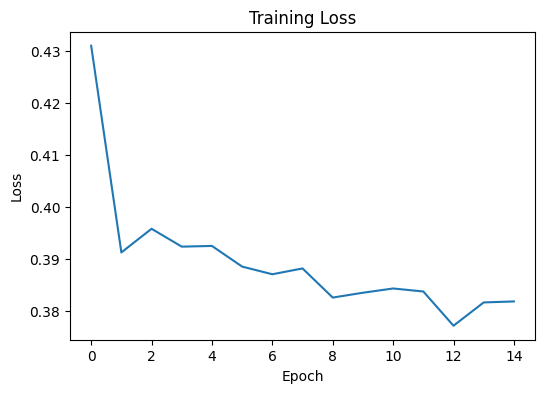

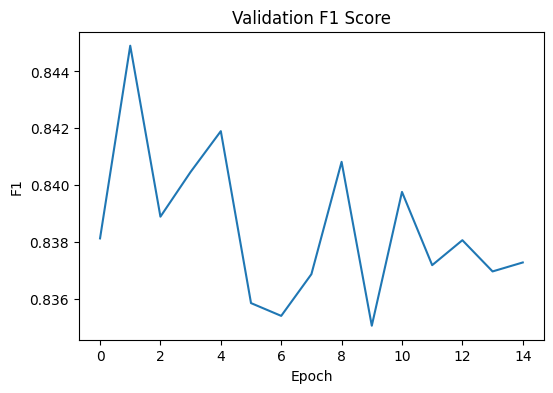

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_f1s)
plt.title("Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.show()

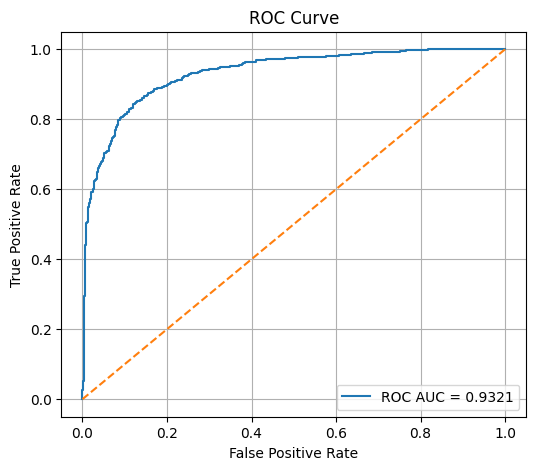

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

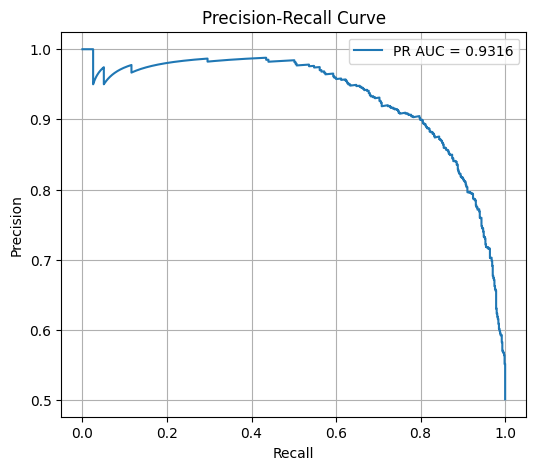

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_probs)
pr_auc = average_precision_score(y_true, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

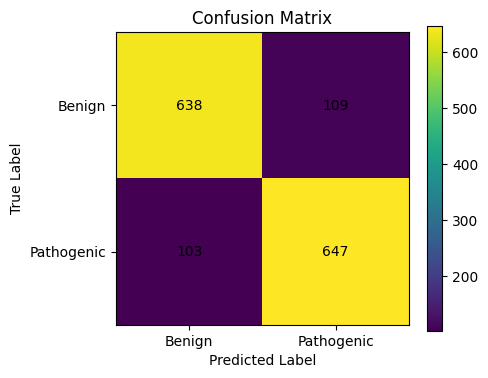

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = (y_probs >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Benign", "Pathogenic"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

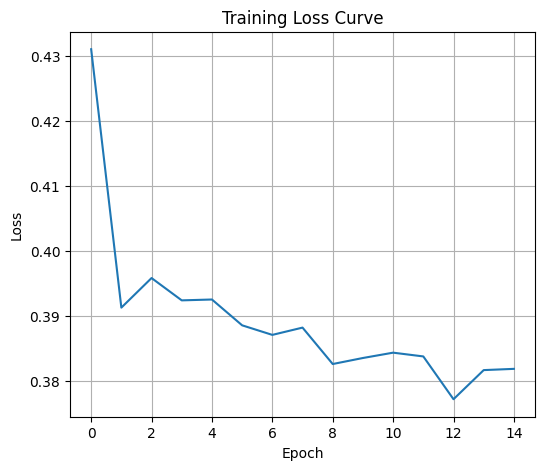

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

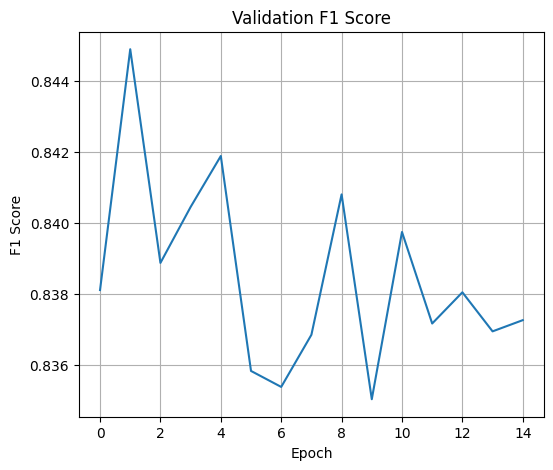

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(val_f1s)
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score")
plt.grid(True)
plt.show()

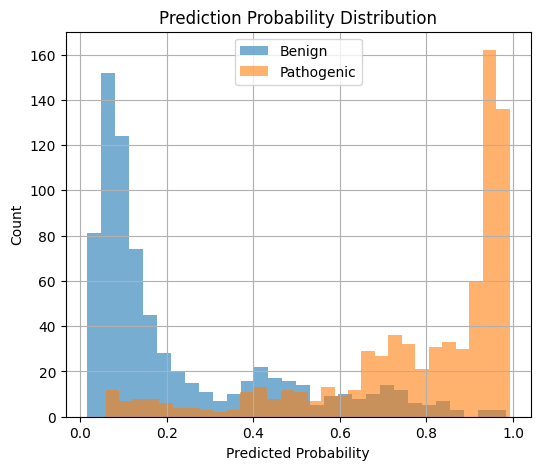

In [ ]:
plt.figure(figsize=(6, 5))
plt.hist(y_probs[y_true == 0], bins=30, alpha=0.6, label="Benign")
plt.hist(y_probs[y_true == 1], bins=30, alpha=0.6, label="Pathogenic")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Prediction Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
torch.save(model, "full_hybrid_model.pth")
print("Full model saved")

Full model saved


In [ ]:
torch.save(model.state_dict(), "best_hybrid_model.pth")
print("Weights saved")

Weights saved


In [ ]:
from google.colab import files

torch.save(model.state_dict(), "best_hybrid_model.pth")
files.download("best_hybrid_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

joblib.dump(scaler, "hybrid_feature_scaler.pkl")
print("Saved scaler as hybrid_feature_scaler.pkl")

Saved scaler as hybrid_feature_scaler.pkl


In [ ]:
from google.colab import files
files.download("hybrid_feature_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
torch.save(model.state_dict(), "hybrid_model_weights.pth")
print("Saved model weights as hybrid_model_weights.pth")

Saved model weights as hybrid_model_weights.pth


In [ ]:
from google.colab import files
files.download("hybrid_model_weights.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

clinvar_small.to_csv("clinvar_hybrid_ready_10k.csv", index=False)
files.download("clinvar_hybrid_ready_10k.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch, joblib

clinvar_small.to_csv("/content/drive/MyDrive/clinvar_hybrid_ready_10k.csv", index=False)
torch.save(model.state_dict(), "/content/drive/MyDrive/hybrid_model_weights.pth")
joblib.dump(scaler, "/content/drive/MyDrive/hybrid_feature_scaler.pkl")

print("All files saved to Google Drive")

All files saved to Google Drive
